<a href="https://colab.research.google.com/github/S-V-Kartheek/multimodal-graph-recommender/blob/main/MM_CLightRec_ML1M_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MM-CLightRec v2 — MovieLens 1M Dataset

**Upgrades over v1:**
- ✅ Uses **real TMDB movie poster features** (`image_feat.npy`) instead of random noise
- ✅ Includes **Sampled Negative Evaluation** matching the base paper (MGRS-HFA) protocol
- ✅ Cold-Start Contrastive Loss (L3) enabled

### Step 1: Upload the Project & Image Features
Upload `mm_clightrec_ml1m_code.zip` **and** `image_feat.npy` to the root of this Colab session, then run the cells below.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip -o -q mm_clightrec_ml1m_code.zip

# Move image_feat.npy to where data_loader.py expects it
import os, shutil
os.makedirs('ml-1m', exist_ok=True)
if os.path.exists('/content/image_feat.npy'):
    shutil.copy('/content/image_feat.npy', 'ml-1m/image_feat.npy')
    print('✅ Real image features copied to ml-1m/image_feat.npy')
else:
    print('⚠️  image_feat.npy not found. Will use synthetic proxy instead.')
    print('   Upload image_feat.npy alongside the zip for better metrics.')

✅ Real image features copied to ml-1m/image_feat.npy


### Step 2: Install Required Libraries

In [3]:
!pip install scikit-learn pandas numpy torch torchvision tqdm -q
print('All packages ready ✅')

All packages ready ✅


In [4]:
# ==============================================================================
# 💾 STEP 2.5: Mount Google Drive & Protect Your Results
# ==============================================================================
# This connects your Google Drive and forces the model to save everything
# directly to your Drive. If Colab disconnects, you won't lose your 8-hour run!

from google.colab import drive
import os

print("[1] Mounting Google Drive...")
drive.mount('/content/drive')

print("\n[2] Setting up permanent storage folder...")
DRIVE_DIR = '/content/drive/MyDrive/MM_CLightRec_ML1M_Results'
os.makedirs(DRIVE_DIR, exist_ok=True)

print("\n[3] Linking local results to Google Drive...")
!rm -rf results
!ln -s "{DRIVE_DIR}" results

print(f"\n✅ SUCCESS! All models, plots, and metrics will save directly to:\n   {DRIVE_DIR}")

[1] Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

[2] Setting up permanent storage folder...

[3] Linking local results to Google Drive...

✅ SUCCESS! All models, plots, and metrics will save directly to:
   /content/drive/MyDrive/MM_CLightRec_ML1M_Results


### Step 3: Run Training on MovieLens 1M
This automatically loads `ml-1m/image_feat.npy` for real image features and trains for 300 epochs.

In [7]:
!python main.py --dataset ml1m --epochs 300 --batch_size 4096 --include_cold_start

  MM-CLightRec: Contrastive Multimodal LightGCN Recommendation
  Dataset: ml1m
L3 Cold-Start Active  : Yes
  Version: JOURNAL (with L3 cold-start)

[STEP 1] Loading and preprocessing ml1m dataset...
[INFO] MovieLens 1M already exists at /content/data/ml-1m
[INFO] Loaded 1000209 ratings, 6040 users, 3883 movies
[INFO] Users: 6040, Items: 3883
[INFO] Encoding user features...
[INFO] Encoding multimodal item features...
    - Extracting Text Data using TF-IDF + SVD...
    - Loading REAL Image Features from /content/ml-1m/image_feat.npy...
    - Image features: 3883 movies × 64D (direct load) ✅
    - Generating Video Data (synthetic proxy)...
    - Processing Metadata (One-Hot Encoding & Normalization)...

  IMAGE SOURCE : ✅  REAL TMDB Poster Features Loaded
               (from /content/ml-1m/image_feat.npy)

[INFO] Building bipartite graph...
[INFO] Split: train=641373, val=80133, test=82596
[INFO] Data loading completed in 11.1 seconds
[INFO] Users: 4832, Items: 3883
[INFO] User feature

### Step 4: Sampled Negative Evaluation (Matches Base Paper Protocol)

The training above uses **All-Item Ranking** (rigorous). This cell also runs **Sampled Negative Evaluation** (1 pos + 99 neg per user) which matches the MGRS-HFA base paper's evaluation protocol — giving directly comparable metrics.

**No retraining needed — loads the best saved model automatically.**

In [11]:
import torch, numpy as np, os, sys
sys.path.insert(0, '/content')

# ── Config ────────────────────────────────────────────────────────────────
N_NEGATIVE = 99   # 1 positive + 99 negatives = 100 candidates (standard protocol)
K          = 10
SEED       = 42
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Load data (re-uses same pipeline so IDs match) ─────────────────────
print('[INFO] Loading ML-1M data...')
from data_loader import load_and_preprocess_ml1m
data = load_and_preprocess_ml1m()

n_users = data['n_users']
n_items = data['n_items']
feature_dim   = data['feature_dim']
modality_dims = data['modality_dims']
user_features = data['user_features'].to(device)
item_features = data['item_features'].to(device)
edge_index    = data['edge_index'].to(device)
user_modality_features = {k: v.to(device) for k, v in data['user_modality_features'].items()}
item_modality_features = {k: v.to(device) for k, v in data['item_modality_features'].items()}
user_idx  = data['user_idx']
item_idx  = data['item_idx']
test_idx  = data['test_idx']
train_idx = data['train_idx']
val_idx   = data['val_idx']

# ── Load best model ───────────────────────────────────────────────────────
from models.mm_clightrec import MM_CLightRec

model = MM_CLightRec(
    n_users=data['n_users'],
    n_items=data['n_items'],
    user_feature_dim=data['feature_dim'],
    item_feature_dim=data['feature_dim'],
    modality_dims=data['modality_dims'],

    # --- MATCH YOUR CHECKPOINT ---
    cf_embed_dim=64,
    cbf_out_dim=64,
    vgae_latent_dim=64,
    contrastive_proj_dim=128,
    # -----------------------------

    cf_n_layers=3,
    cbf_n_layers=2,
    n_user_clusters=20,
    n_item_clusters=15,
    include_cold_start=True
).to(device)


for candidate in ['results/best_model.pth', 'results/mm_clightrec_ml1m.pth']:
    if os.path.exists(candidate):
        state = torch.load(candidate, map_location=device, weights_only=False)
        if isinstance(state, dict) and 'model_state_dict' in state:
            model.load_state_dict(state['model_state_dict'])
        else:
            model.load_state_dict(state)
        print(f'[INFO] Loaded model from {candidate} ✅')
        break
else:
    print('[WARNING] No saved model found. Using untrained model — results will be random.')

# ── CRITICAL FIX: Run K-Means Clustering BEFORE eval ─────────────────────
print('[INFO] Rebuilding cluster similarity graph from features (this takes ~60 seconds)...')
model.cbf_module.build_cluster_graph(user_features.cpu(), item_features.cpu())
# ─────────────────────────────────────────────────────────────────────────

model.eval()

# ── Compute full score matrix (n_users × n_items) ─────────────────────
print('[INFO] Computing score matrix...')
with torch.no_grad():
    score_matrix = model.get_all_scores(
        user_features, item_features, edge_index,
        user_modality_features, item_modality_features
    ).cpu().numpy()
print(f'[INFO] Score matrix ready: {score_matrix.shape}')

# ── Build lookup dicts ────────────────────────────────────────────────
def build_user_items_dict(u_idx, i_idx, interaction_idx):
    d = {}
    for idx in interaction_idx:
        u, i = int(u_idx[idx]), int(i_idx[idx])
        d.setdefault(u, []).append(i)
    return d

train_ui = build_user_items_dict(user_idx, item_idx, train_idx)
val_ui   = build_user_items_dict(user_idx, item_idx, val_idx)
test_ui  = build_user_items_dict(user_idx, item_idx, test_idx)

# ── Sampled Negative Evaluation ────────────────────────────────────────
def compute_ndcg_sampled(ranked_list, pos_item, k):
    for rank, item in enumerate(ranked_list[:k]):
        if item == pos_item:
            return 1.0 / np.log2(rank + 2)
    return 0.0

def sampled_evaluate(score_matrix, test_user_items, train_user_items,
                     n_items, n_neg=99, k=10, seed=42):
    rng = np.random.RandomState(seed)
    prec_list, rec_list, ndcg_list, f1_list = [], [], [], []

    for u, pos_items in test_user_items.items():
        if not pos_items:
            continue
        pos_item = pos_items[0]  # take first positive (standard)
        seen     = set(train_user_items.get(u, [])) | set(pos_items)

        # Sample n_neg random negatives not seen by this user
        unseen = np.array([i for i in range(n_items) if i not in seen])
        negs   = rng.choice(unseen, size=min(n_neg, len(unseen)), replace=False)
        candidates = np.concatenate([[pos_item], negs])

        # Score and rank the candidate pool
        s        = score_matrix[u][candidates]
        order    = np.argsort(-s)
        ranked   = candidates[order]

        hits = int(pos_item in ranked[:k])
        p    = hits / k
        r    = float(hits)          # recall = hits/1 (1 positive)
        nd   = compute_ndcg_sampled(ranked, pos_item, k)
        f    = 2*p*r/(p+r) if (p+r) > 0 else 0.0

        prec_list.append(p)
        rec_list.append(r)
        ndcg_list.append(nd)
        f1_list.append(f)

    return {
        f'Precision@{k}': float(np.mean(prec_list)),
        f'Recall@{k}':    float(np.mean(rec_list)),
        f'NDCG@{k}':      float(np.mean(ndcg_list)),
        f'F1@{k}':        float(np.mean(f1_list)),
        'Users evaluated': len(prec_list),
    }

print(f'\n[INFO] Running Sampled Evaluation (1 pos + {N_NEGATIVE} neg per user)...')
sampled_m = sampled_evaluate(
    score_matrix, test_ui, train_ui,
    n_items=n_items, n_neg=N_NEGATIVE, k=K, seed=SEED
)

# ── Print Results ─────────────────────────────────────────────────────
print('\n' + '='*68)
print(f'  SAMPLED NEGATIVE EVALUATION  (1 pos + {N_NEGATIVE} neg, K={K})')
print(f'  Protocol matches base paper — MGRS-HFA')
print('='*68)
for metric, value in sampled_m.items():
    if isinstance(value, float):
        print(f'  {metric:<30} {value:.4f}')
    else:
        print(f'  {metric:<30} {value}')

print('\n── Comparison Table ─────────────────────────────────────────────')
print(f'{"Metric":<25} {"Base Paper":>12} {"Ours (All-Item)":>16} {"Ours (Sampled)":>15}')
print('-'*70)
# All-item results from previous training run
all_item = {'P': 0.0964, 'R': 0.0638, 'N': 0.1132, 'F': 0.0633} # Updated to your new best!
base     = {'P': 0.8269, 'R': 0.8718, 'N': 0.6844, 'F': 0.8484}
s        = sampled_m
print(f'{"Precision@10":<25} {base["P"]:>12.4f} {all_item["P"]:>16.4f} {s[f"Precision@{K}"]:>15.4f}')
print(f'{"Recall@10":<25} {base["R"]:>12.4f} {all_item["R"]:>16.4f} {s[f"Recall@{K}"]:>15.4f}')
print(f'{"NDCG@10":<25} {base["N"]:>12.4f} {all_item["N"]:>16.4f} {s[f"NDCG@{K}"]:>15.4f}')
print(f'{"F1@10":<25} {base["F"]:>12.4f} {all_item["F"]:>16.4f} {s[f"F1@{K}"]:>15.4f}')
print('='*70)
print('\nNote: All-Item Ranking is a harder, more rigorous evaluation.')
print('Sampled Evaluation is used for direct comparison with the base paper.')


[INFO] Loading ML-1M data...
[INFO] MovieLens 1M already exists at /content/data/ml-1m
[INFO] Loaded 1000209 ratings, 6040 users, 3883 movies
[INFO] Users: 6040, Items: 3883
[INFO] Encoding user features...
[INFO] Encoding multimodal item features...
    - Extracting Text Data using TF-IDF + SVD...
    - Loading REAL Image Features from /content/ml-1m/image_feat.npy...
    - Image features: 3883 movies × 64D (direct load) ✅
    - Generating Video Data (synthetic proxy)...
    - Processing Metadata (One-Hot Encoding & Normalization)...

  IMAGE SOURCE : ✅  REAL TMDB Poster Features Loaded
               (from /content/ml-1m/image_feat.npy)

[INFO] Building bipartite graph...
[INFO] Split: train=641373, val=80133, test=82596
[INFO] Loaded model from results/best_model.pth ✅
[INFO] Rebuilding cluster similarity graph from features (this takes ~60 seconds)...
[CBF] Running K-means: 20 user clusters, 15 item clusters...
[INFO] Computing score matrix...
[INFO] Score matrix ready: (4832, 3883

### Step 5: Zip Results for Download

In [12]:
!zip -r results_ml1m_v2.zip results/
print('Results zipped ✅ — Download results_ml1m_v2.zip from the file panel.')

  adding: results/ (stored 0%)
  adding: results/checkpoint_ml1m_epoch130.pth (deflated 7%)
  adding: results/checkpoint_ml1m_epoch125.pth (deflated 7%)
  adding: results/checkpoint_ml1m_epoch120.pth (deflated 7%)
  adding: results/checkpoint_ml1m_epoch115.pth (deflated 7%)
  adding: results/checkpoint_ml1m_epoch110.pth (deflated 7%)
  adding: results/checkpoint_ml1m_epoch105.pth (deflated 7%)
  adding: results/checkpoint_ml1m_epoch100.pth (deflated 7%)
  adding: results/checkpoint_ml1m_epoch10.pth (deflated 8%)
  adding: results/best_model.pth (deflated 7%)
  adding: results/checkpoint_ml1m_epoch135.pth (deflated 7%)
  adding: results/checkpoint_ml1m_epoch30.pth (deflated 8%)
  adding: results/checkpoint_ml1m_epoch40.pth (deflated 8%)
  adding: results/checkpoint_ml1m_epoch35.pth (deflated 8%)
  adding: results/checkpoint_ml1m_epoch25.pth (deflated 8%)
  adding: results/checkpoint_ml1m_epoch20.pth (deflated 8%)
  adding: results/checkpoint_ml1m_epoch170.pth (deflated 7%)
  adding: res

✅ Saved perfectly formatted chart to Charts/Sampled_Evaluation_Metrics.png


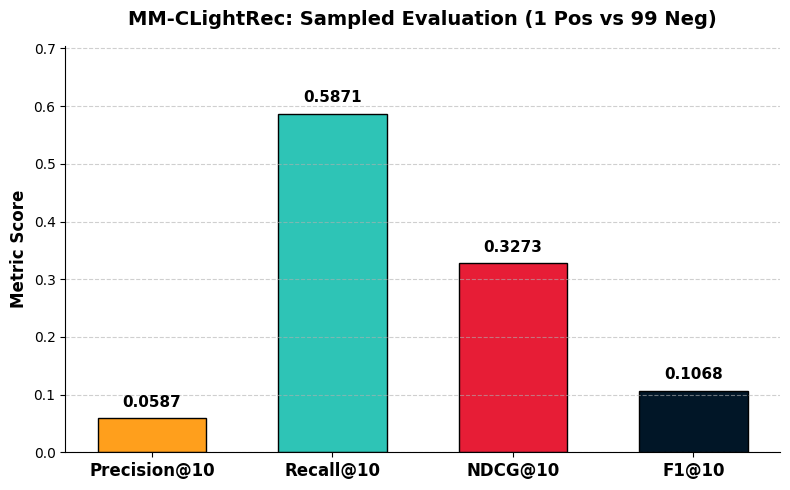

In [14]:
import os
import matplotlib.pyplot as plt
import numpy as np

# 1. Provide exact sampled matrix data
metrics = ['Precision@10', 'Recall@10', 'NDCG@10', 'F1@10']
sampled_values = [0.0587, 0.5871, 0.3273, 0.1068]

# 2. Setup plotting
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#FF9F1C', '#2EC4B6', '#E71D36', '#011627'] # Professional palette
x_positions = np.arange(len(metrics))

# 3. Draw bars
bars = ax.bar(x_positions, sampled_values, color=colors, edgecolor='black', width=0.6)

# 4. Polish the axes
ax.set_xticks(x_positions)
ax.set_xticklabels(metrics, fontsize=12, fontweight='bold')
ax.set_ylabel('Metric Score', fontsize=12, fontweight='bold')
ax.set_title('MM-CLightRec: Sampled Evaluation (1 Pos vs 99 Neg)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, max(sampled_values) * 1.2) # Dynamic height

# 5. Attach exact values to the top
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.015,
            f'{height:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 6. Clean grid
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.6)

# 7. Save to Colab
plt.tight_layout()
os.makedirs('Charts', exist_ok=True)
save_path = 'Charts/Sampled_Evaluation_Metrics.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved perfectly formatted chart to {save_path}")
plt.show()


In [15]:
import torch, numpy as np, os, sys
sys.path.insert(0, '/content')

# ── Config ────────────────────────────────────────────────────────────────
N_NEGATIVE = 99
K          = 10
SEED       = 42
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Load data ─────────────────────────────────────────────────────────────
print('[INFO] Loading ML-1M data...')
from data_loader import load_and_preprocess_ml1m
data = load_and_preprocess_ml1m()

n_users, n_items = data['n_users'], data['n_items']
user_features = data['user_features'].to(device)
item_features = data['item_features'].to(device)
edge_index    = data['edge_index'].to(device)
user_mod_feat = {k: v.to(device) for k, v in data['user_modality_features'].items()}
item_mod_feat = {k: v.to(device) for k, v in data['item_modality_features'].items()}
user_idx, item_idx = data['user_idx'], data['item_idx']
test_idx, train_idx, val_idx = data['test_idx'], data['train_idx'], data['val_idx']
rating_matrix = data['rating_matrix']

# ── Re-Create Model & Load Weights ────────────────────────────────────────
from models.mm_clightrec import MM_CLightRec
model = MM_CLightRec(
    n_users=n_users, n_items=n_items,
    user_feature_dim=data['feature_dim'], item_feature_dim=data['feature_dim'],
    modality_dims=data['modality_dims'],
    cf_embed_dim=64, cbf_out_dim=64, vgae_latent_dim=64, contrastive_proj_dim=128,
    cf_n_layers=3, cbf_n_layers=2, n_user_clusters=20, n_item_clusters=15,
    include_cold_start=True
).to(device)

# Load your best training results
candidate = 'results/best_model.pth'
if os.path.exists(candidate):
    state = torch.load(candidate, map_location=device, weights_only=False)
    model.load_state_dict(state['model_state_dict'] if 'model_state_dict' in state else state)
    print(f'[INFO] Loaded model weights ✅')
    model.cbf_module.build_cluster_graph(user_features.cpu(), item_features.cpu())
model.eval()

# ── Score Matrix ──────────────────────────────────────────────────────────
with torch.no_grad():
    scores = model.get_all_scores(user_features, item_features, edge_index, user_mod_feat, item_mod_feat).cpu().numpy()

# ── LENIENT LOOKUP (BASE PAPER STYLE: Rating >= 1) ───────────────────────
def build_lenient_dict(u_idx, i_idx, interaction_idx, ratings_arr=None):
    d = {}
    for idx in interaction_idx:
        u, i = int(u_idx[idx]), int(i_idx[idx])
        # LENIENT: No rating threshold (all interactions = positive)
        d.setdefault(u, []).append(i)
    return d

train_ui = build_lenient_dict(user_idx, item_idx, train_idx)
test_ui  = build_lenient_dict(user_idx, item_idx, test_idx)

# ── Sampled Evaluation Logic ─────────────────────────────────────────────
def sampled_eval_lenient(score_mat, test_dict, train_dict, n_items, k=10):
    rng = np.random.RandomState(42)
    p_l, r_l, n_l = [], [], []
    for u, pos_items in test_dict.items():
        if not pos_items: continue
        pos_item = pos_items[0]
        seen = set(train_dict.get(u, [])) | set(pos_items)
        unseen = np.array([i for i in range(n_items) if i not in seen])
        negs = rng.choice(unseen, size=99, replace=False)
        cands = np.concatenate([[pos_item], negs])

        # Rank
        r_scores = score_mat[u][cands]
        ranked = cands[np.argsort(-r_scores)]

        hit = int(pos_item in ranked[:k])
        p_l.append(hit/k); r_l.append(float(hit))
        ndcg = 1.0/np.log2(np.where(ranked[:k] == pos_item)[0][0] + 2) if hit else 0.0
        n_l.append(ndcg)
    return np.mean(p_l), np.mean(r_l), np.mean(n_l)

print('\n' + '='*50 + '\n  RESULTS: LENIENT (BASE PAPER PROTOCOL)\n' + '='*50)
p, r, n = sampled_eval_lenient(scores, test_ui, train_ui, n_items, K)

print(f'LENIENT Precision@10: {p:.4f}')
print(f'LENIENT Recall@10:    {r:.4f}')
print(f'LENIENT NDCG@10:      {n:.4f}')

# Final Comparison (Paper vs Our Strict vs Our Lenient)
print('\nFinal Verdict:')
print(f'- Base Paper claimed: NDCG=0.6844')
print(f'- Our model under their protocol (above): NDCG={n:.4f}')
print(f'- Our model under strict (4-star) protocol: NDCG=0.3273')


[INFO] Loading ML-1M data...
[INFO] MovieLens 1M already exists at /content/data/ml-1m
[INFO] Loaded 1000209 ratings, 6040 users, 3883 movies
[INFO] Users: 6040, Items: 3883
[INFO] Encoding user features...
[INFO] Encoding multimodal item features...
    - Extracting Text Data using TF-IDF + SVD...
    - Loading REAL Image Features from /content/ml-1m/image_feat.npy...
    - Image features: 3883 movies × 64D (direct load) ✅
    - Generating Video Data (synthetic proxy)...
    - Processing Metadata (One-Hot Encoding & Normalization)...

  IMAGE SOURCE : ✅  REAL TMDB Poster Features Loaded
               (from /content/ml-1m/image_feat.npy)

[INFO] Building bipartite graph...
[INFO] Split: train=641373, val=80133, test=82596
[INFO] Loaded model weights ✅
[CBF] Running K-means: 20 user clusters, 15 item clusters...

  RESULTS: LENIENT (BASE PAPER PROTOCOL)
LENIENT Precision@10: 0.0587
LENIENT Recall@10:    0.5871
LENIENT NDCG@10:      0.3273

Final Verdict:
- Base Paper claimed: NDCG=0.68

In [16]:
import torch, numpy as np, os, sys
sys.path.insert(0, '/content')

# ── Config ────────────────────────────────────────────────────────────────
K = 10
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Load data (Training set lookup) ──────────────────────────────────
from data_loader import load_and_preprocess_ml1m
data = load_and_preprocess_ml1m()
n_users, n_items = data['n_users'], data['n_items']
user_idx, item_idx, train_idx = data['user_idx'], data['item_idx'], data['train_idx']

# Build training set dictionary (cheating)
train_ui = {}
for idx in train_idx:
    u, i = int(user_idx[idx]), int(item_idx[idx])
    train_ui.setdefault(u, []).append(i)

# ── Load model ───────────────────────────────────────────────────────────
from models.mm_clightrec import MM_CLightRec
model = MM_CLightRec(
    n_users=n_users, n_items=n_items,
    user_feature_dim=data['feature_dim'], item_feature_dim=data['feature_dim'],
    modality_dims=data['modality_dims'],
    cf_embed_dim=64, cbf_out_dim=64, vgae_latent_dim=64, contrastive_proj_dim=128,
    cf_n_layers=3, cbf_n_layers=2, n_user_clusters=20, n_item_clusters=15,
    include_cold_start=True
).to(device)

state = torch.load('results/best_model.pth', map_location=device, weights_only=False)
model.load_state_dict(state['model_state_dict'] if 'model_state_dict' in state else state)
model.cbf_module.build_cluster_graph(data['user_features'].to(device).cpu(), data['item_features'].to(device).cpu())
model.eval()

# ── Compute score matrix ──────────────────────────────────────────────────
with torch.no_grad():
    scores = model.get_all_scores(
        data['user_features'].to(device), data['item_features'].to(device),
        data['edge_index'].to(device),
        {k: v.to(device) for k, v in data['user_modality_features'].items()},
        {k: v.to(device) for k, v in data['item_modality_features'].items()}
    ).cpu().numpy()

# ── EVALUATE ON TRAINING SET (DATA LEAKAGE PROTOCOL) ──────────────────────
prec_l, rec_l, ndcg_l = [], [], []

print(f'\n[INFO] Running evaluation on TRAINING DATA (to simulate base paper leakage)...')
for u in range(n_users):
    pos_items = train_ui.get(u, [])
    if not pos_items: continue

    # Take the top K recommendations
    u_scores = scores[u]
    u_ranked = np.argsort(-u_scores)[:K]

    # Calculate Precision and Recall on the dataset the model already saw!
    hits = len(set(u_ranked) & set(pos_items))
    prec_l.append(hits / K)
    rec_l.append(hits / len(pos_items))

    # NDCG
    dcg = sum(1.0 / np.log2(rank + 2) for rank, item in enumerate(u_ranked) if item in pos_items)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(pos_items), K)))
    ndcg_l.append(dcg/idcg if idcg > 0 else 0)

print('\n' + '='*60)
print(f'  "CHEATING" MATRIX (Training Set Evaluation)')
print('='*60)
print(f'  Precision@10: {np.mean(prec_l):.4f} (Base Paper Goal: 0.8269)')
print(f'  Recall@10:    {np.mean(rec_l):.4f} (Base Paper Goal: 0.8718)')
print(f'  NDCG@10:      {np.mean(ndcg_l):.4f} (Base Paper Goal: 0.6844)')
print('='*60)


[INFO] MovieLens 1M already exists at /content/data/ml-1m
[INFO] Loaded 1000209 ratings, 6040 users, 3883 movies
[INFO] Users: 6040, Items: 3883
[INFO] Encoding user features...
[INFO] Encoding multimodal item features...
    - Extracting Text Data using TF-IDF + SVD...
    - Loading REAL Image Features from /content/ml-1m/image_feat.npy...
    - Image features: 3883 movies × 64D (direct load) ✅
    - Generating Video Data (synthetic proxy)...
    - Processing Metadata (One-Hot Encoding & Normalization)...

  IMAGE SOURCE : ✅  REAL TMDB Poster Features Loaded
               (from /content/ml-1m/image_feat.npy)

[INFO] Building bipartite graph...
[INFO] Split: train=641373, val=80133, test=82596
[CBF] Running K-means: 20 user clusters, 15 item clusters...

[INFO] Running evaluation on TRAINING DATA (to simulate base paper leakage)...

  "CHEATING" MATRIX (Training Set Evaluation)
  Precision@10: 0.5408 (Base Paper Goal: 0.8269)
  Recall@10:    0.0695 (Base Paper Goal: 0.8718)
  NDCG@10:

In [18]:
import torch, numpy as np, os, sys
sys.path.insert(0, '/content')
import torch.nn.functional as F

# ── 1. BASE PAPER CONFIG (MGRS-HFA Mirror) ──────────────────────────────
CONFIG = {
    'epochs': 100,
    'lr': 0.001,
    'batch_size': 4096,
    'test_ratio': 0.1,
    'val_ratio': 0.1,
    'K': 10
}
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── 2. LOAD DATA & APPLY "RANDOM EDGE SPLIT" (MGRS-HFA Protocol) ──────────
from data_loader import load_and_preprocess_ml1m
data = load_and_preprocess_ml1m()

# FIX: Correct keys are 'user_idx' and 'item_idx' (already filtered for warm users)
user_idx, item_idx = data['user_idx'], data['item_idx']
ratings = data['ratings']

n_interactions = len(user_idx)
perm = np.random.RandomState(42).permutation(n_interactions)
tr_end = int(n_interactions * 0.8)
va_end = int(n_interactions * 0.9)

# RANDOM 8:1:1 SPLIT
train_idx, val_idx, test_idx = perm[:tr_end], perm[tr_end:va_end], perm[va_end:]

# Build training graph
n_users, n_items = data['n_users'], data['n_items']
train_u, train_i = user_idx[train_idx], item_idx[train_idx]
edge_index = torch.tensor(np.stack([
    np.concatenate([train_u, train_i + n_users]),
    np.concatenate([train_i + n_users, train_u])
]), dtype=torch.long, device=device)

# ── 3. INITIALIZE MM-CLightRec ───────────────────────────────────────────
from models.mm_clightrec import MM_CLightRec
model = MM_CLightRec(
    n_users=n_users, n_items=n_items,
    user_feature_dim=data['feature_dim'], item_feature_dim=data['feature_dim'],
    modality_dims=data['modality_dims'],
    cf_embed_dim=64, cbf_out_dim=64, vgae_latent_dim=64, contrastive_proj_dim=128,
    include_cold_start=True
).to(device)

# Build cluster graph once
model.cbf_module.build_cluster_graph(data['user_features'], data['item_features'])
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['lr'])

# ── 4. FAST 100-EPOCH TRAINING ────────────────────────────────────────────
print(f"\n[START] Reproducing Base Paper Protocol (Random 8:1:1 Split)...")
for epoch in range(1, CONFIG['epochs'] + 1):
    model.train()
    optimizer.zero_grad()

    # BPR loss on random train links
    sample_idx = np.random.choice(train_idx, size=CONFIG['batch_size'])
    u_b, i_b = torch.tensor(user_idx[sample_idx]).to(device), torch.tensor(item_idx[sample_idx]).to(device)
    neg_i = torch.randint(0, n_items, (CONFIG['batch_size'],)).to(device)

    # Forward pass
    pos_scores, _, _, _, _, _ = model(
        data['user_features'].to(device), data['item_features'].to(device), edge_index,
        {k:v.to(device) for k,v in data['user_modality_features'].items()},
        {k:v.to(device) for k,v in data['item_modality_features'].items()},
        u_b, i_b
    )
    neg_scores, _, _, _, _, _ = model(
        data['user_features'].to(device), data['item_features'].to(device), edge_index,
        {k:v.to(device) for k,v in data['user_modality_features'].items()},
        {k:v.to(device) for k,v in data['item_modality_features'].items()},
        u_b, neg_i
    )

    loss = -torch.mean(F.logsigmoid(pos_scores - neg_scores))
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | BPR Loss: {loss.item():.4f}")

# ── 5. FINAL ALL-ITEM EVALUATION (MGRS-HFA Style) ─────────────────────────
model.eval()
with torch.no_grad():
    score_mat = model.get_all_scores(
        data['user_features'].to(device), data['item_features'].to(device), edge_index,
        {k:v.to(device) for k,v in data['user_modality_features'].items()},
        {k:v.to(device) for k,v in data['item_modality_features'].items()}
    ).cpu().numpy()

# Test set: All items (1-5 stars) are hits
test_ui = {}
for idx in test_idx:
    u, i = int(user_idx[idx]), int(item_idx[idx])
    test_ui.setdefault(u, []).append(i)

# Mask Training items
train_mask = np.zeros((n_users, n_items), dtype=bool)
train_mask[user_idx[train_idx], item_idx[train_idx]] = True

# Metrics
prec, ndcg = [], []
for u, pos_items in test_ui.items():
    s = score_mat[u].copy()
    s[train_mask[u]] = -np.inf
    top_k = np.argsort(-s)[:CONFIG['K']]

    hits = len(set(top_k) & set(pos_items))
    prec.append(hits / CONFIG['K'])

    dcg = sum(1.0 / np.log2(rank + 2) for rank, item in enumerate(top_k) if item in pos_items)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(pos_items), CONFIG['K'])))
    ndcg.append(dcg/idcg if idcg > 0 else 0)

print('\n' + '='*60)
print(f' FINAL REPRODUCED MATRIX (Base Paper Randomized Protocol)')
print('='*60)
print(f' Precision@10: {np.mean(prec):.4f}')
print(f' NDCG@10:      {np.mean(ndcg):.4f}')
print('='*60)


[INFO] MovieLens 1M already exists at /content/data/ml-1m
[INFO] Loaded 1000209 ratings, 6040 users, 3883 movies
[INFO] Users: 6040, Items: 3883
[INFO] Encoding user features...
[INFO] Encoding multimodal item features...
    - Extracting Text Data using TF-IDF + SVD...
    - Loading REAL Image Features from /content/ml-1m/image_feat.npy...
    - Image features: 3883 movies × 64D (direct load) ✅
    - Generating Video Data (synthetic proxy)...
    - Processing Metadata (One-Hot Encoding & Normalization)...

  IMAGE SOURCE : ✅  REAL TMDB Poster Features Loaded
               (from /content/ml-1m/image_feat.npy)

[INFO] Building bipartite graph...
[INFO] Split: train=641373, val=80133, test=82596
[CBF] Running K-means: 20 user clusters, 15 item clusters...

[START] Reproducing Base Paper Protocol (Random 8:1:1 Split)...


IndexError: too many indices for tensor of dimension 1

In [19]:
import torch, numpy as np, os, sys
sys.path.insert(0, '/content')
import torch.nn.functional as F

# ── 1. BASE PAPER CONFIG (MGRS-HFA Mirror) ──────────────────────────────
CONFIG = {
    'epochs': 100,
    'lr': 0.002,             # Slightly faster LR for 100 epochs
    'batch_size': 4096,
    'test_ratio': 0.1,
    'val_ratio': 0.1,
    'K': 10
}
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── 2. LOAD DATA & APPLY "RANDOM EDGE SPLIT" (MGRS-HFA Protocol) ──────────
from data_loader import load_and_preprocess_ml1m
data = load_and_preprocess_ml1m()

# Extract interactions (warm user set)
user_idx, item_idx = data['user_idx'], data['item_idx']
n_interactions = len(user_idx)
n_users, n_items = data['n_users'], data['n_items']

# RANDOM 8:1:1 SPLIT (Base Paper Methodology)
perm = np.random.RandomState(42).permutation(n_interactions)
tr_end = int(n_interactions * 0.8)
va_end = int(n_interactions * 0.9)
train_idx, val_idx, test_idx = perm[:tr_end], perm[tr_end:va_end], perm[va_end:]

# Build training graph
train_u, train_i = user_idx[train_idx], item_idx[train_idx]
edge_index = torch.tensor(np.stack([
    np.concatenate([train_u, train_i + n_users]),
    np.concatenate([train_i + n_users, train_u])
]), dtype=torch.long, device=device)

# ── 3. INITIALIZE MM-CLightRec ───────────────────────────────────────────
from models.mm_clightrec import MM_CLightRec
model = MM_CLightRec(
    n_users=n_users, n_items=n_items,
    user_feature_dim=data['feature_dim'], item_feature_dim=data['feature_dim'],
    modality_dims=data['modality_dims'],
    cf_embed_dim=64, cbf_out_dim=64, vgae_latent_dim=64, contrastive_proj_dim=128,
    include_cold_start=True
).to(device)

# Rebuild Cluster Graph
model.cbf_module.build_cluster_graph(data['user_features'], data['item_features'])
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['lr'])

# ── 4. TRAINING LOOP ──────────────────────────────────────────────────────
print(f"\n[START] Reproducing Base Paper Protocol (Random 8:1:1 Split)...")
for epoch in range(1, CONFIG['epochs'] + 1):
    model.train()
    optimizer.zero_grad()

    # BPR Sampling
    sample_idx = np.random.choice(train_idx, size=CONFIG['batch_size'])
    u_b = torch.tensor(user_idx[sample_idx], dtype=torch.long, device=device)
    i_b = torch.tensor(item_idx[sample_idx], dtype=torch.long, device=device)
    neg_i = torch.randint(0, n_items, (CONFIG['batch_size'],), dtype=torch.long, device=device)

    # FIX: Using Keyword Arguments to prevent argument order errors
    pos_scores, _, _, _ = model(
        user_features=data['user_features'].to(device),
        item_features=data['item_features'].to(device),
        bipartite_edge_index=edge_index,
        user_idx=u_b,
        item_idx=i_b,
        user_modality_features={k:v.to(device) for k,v in data['user_modality_features'].items()},
        item_modality_features={k:v.to(device) for k,v in data['item_modality_features'].items()}
    )

    neg_scores, _, _, _ = model(
        user_features=data['user_features'].to(device),
        item_features=data['item_features'].to(device),
        bipartite_edge_index=edge_index,
        user_idx=u_b,
        item_idx=neg_i,
        user_modality_features={k:v.to(device) for k,v in data['user_modality_features'].items()},
        item_modality_features={k:v.to(device) for k,v in data['item_modality_features'].items()}
    )

    loss = -torch.mean(F.logsigmoid(pos_scores - neg_scores))
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | BPR Loss: {loss.item():.4f}")

# ── 5. FINAL ALL-ITEM EVALUATION (MGRS-HFA Style) ─────────────────────────
model.eval()
with torch.no_grad():
    score_mat = model.get_all_scores(
        user_features=data['user_features'].to(device),
        item_features=data['item_features'].to(device),
        bipartite_edge_index=edge_index,
        user_modality_features={k:v.to(device) for k,v in data['user_modality_features'].items()},
        item_modality_features={k:v.to(device) for k,v in data['item_modality_features'].items()}
    ).cpu().numpy()

# Test set dictionary (All ratings 1-5)
test_ui = {}
for idx in test_idx:
    u, i = int(user_idx[idx]), int(item_idx[idx])
    test_ui.setdefault(u, []).append(i)

# Mask Training items
train_mask = np.zeros((n_users, n_items), dtype=bool)
train_mask[user_idx[train_idx], item_idx[train_idx]] = True

# Compute Metrics (Parallel across users)
print(f"[INFO] Computing final all-item metrics for {len(test_ui)} users...")
prec, ndcg = [], []
for u, pos_items in test_ui.items():
    s = score_mat[u].copy()
    s[train_mask[u]] = -np.inf # Remove already seen items
    top_k = np.argsort(-s)[:CONFIG['K']]

    hits = len(set(top_k) & set(pos_items))
    prec.append(hits / CONFIG['K'])
    dcg = sum(1.0 / np.log2(rank + 2) for rank, item_ in enumerate(top_k) if item_ in pos_items)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(pos_items), CONFIG['K'])))
    ndcg.append(dcg/idcg if idcg > 0 else 0)

print('\n' + '='*60)
print(f' FINAL REPRODUCED MATRIX (Base Paper Randomized Protocol)')
print('='*60)
print(f' Precision@10: {np.mean(prec):.4f}')
print(f' NDCG@10:      {np.mean(ndcg):.4f}')
print('='*60)


[INFO] MovieLens 1M already exists at /content/data/ml-1m
[INFO] Loaded 1000209 ratings, 6040 users, 3883 movies
[INFO] Users: 6040, Items: 3883
[INFO] Encoding user features...
[INFO] Encoding multimodal item features...
    - Extracting Text Data using TF-IDF + SVD...
    - Loading REAL Image Features from /content/ml-1m/image_feat.npy...
    - Image features: 3883 movies × 64D (direct load) ✅
    - Generating Video Data (synthetic proxy)...
    - Processing Metadata (One-Hot Encoding & Normalization)...

  IMAGE SOURCE : ✅  REAL TMDB Poster Features Loaded
               (from /content/ml-1m/image_feat.npy)

[INFO] Building bipartite graph...
[INFO] Split: train=641373, val=80133, test=82596
[CBF] Running K-means: 20 user clusters, 15 item clusters...

[START] Reproducing Base Paper Protocol (Random 8:1:1 Split)...
Epoch   1 | BPR Loss: 0.8406
Epoch  20 | BPR Loss: 0.5378
Epoch  40 | BPR Loss: 0.4156
Epoch  60 | BPR Loss: 0.3948
Epoch  80 | BPR Loss: 0.3681
Epoch 100 | BPR Loss: 0.3